# 05: Regularization (Ridge and Smoothing)

## Learning objectives
- Compare unregularized and regularized slip inversions.
- Use map-view plots to inspect slip smoothness and data fit.
- Plot vectors (horizontal) and filled circles (vertical) with fault patches.

We solve:

$$
\|G\mathbf{s} - \mathbf{d}\|_2^2 + \lambda^2\|L\mathbf{s}\|_2^2
$$

with:
- **ridge**: $L = I$
- **smoothing**: $L$ is first-difference operator along patch index

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import lsq_linear
import okada85
import okada_utils

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

rng = np.random.default_rng(8)

In [2]:
def plot_fault_patches(ax, patches, slip, cmap='YlOrRd', vmin=None, vmax=None):
    polys = [okada_utils.fault_outline(p['depth'], p['dip'], p['L'], p['W'], p['strike'], p['e'], p['n']) for p in patches]
    slip = np.asarray(slip)
    if vmin is None:
        vmin = float(np.min(slip))
    if vmax is None:
        vmax = float(np.max(slip))
    mapper = cm.ScalarMappable(norm=mcolors.Normalize(vmin=vmin, vmax=vmax), cmap=cmap)

    for poly, s in zip(polys, slip):
        ax.fill(poly[:, 0] / 1000.0, poly[:, 1] / 1000.0, color=mapper.to_rgba(float(s)), edgecolor='k', linewidth=0.6)

    return mapper


def plot_data_overlay(ax, obs_e, obs_n, uE, uN, uU, uE_pred=None, uN_pred=None, quiver_step=2, quiver_scale=0.1):
    eu = np.unique(obs_e)
    nu = np.unique(obs_n)
    nx, ny = eu.size, nu.size
    E = obs_e.reshape(ny, nx)
    N = obs_n.reshape(ny, nx)
    UE = uE.reshape(ny, nx)
    UN = uN.reshape(ny, nx)

    # Plot original data (black)
    sc = ax.quiver(E[::quiver_step, ::quiver_step] / 1000.0,
              N[::quiver_step, ::quiver_step] / 1000.0,
              UE[::quiver_step, ::quiver_step],
              UN[::quiver_step, ::quiver_step],
              color='k', scale=quiver_scale, width=0.003, label='Observed')

    # Plot predicted data (red) if provided
    if uE_pred is not None and uN_pred is not None:
        UE_pred = uE_pred.reshape(ny, nx)
        UN_pred = uN_pred.reshape(ny, nx)
        ax.quiver(E[::quiver_step, ::quiver_step] / 1000.0,
                  N[::quiver_step, ::quiver_step] / 1000.0,
                  UE_pred[::quiver_step, ::quiver_step],
                  UN_pred[::quiver_step, ::quiver_step],
                  color='r', scale=quiver_scale, width=0.003, label='Predicted')
    if uU is not None:
        sc = ax.scatter(obs_e / 1000.0, obs_n / 1000.0, c=uU, cmap='RdBu_r', s=24, edgecolor='k', linewidth=0.2)
    return sc

In [3]:
# Build synthetic fault + observations
fault_x0 = 0.0
fault_y0 = 0.0
fault_z0 = 8.0e3
fault_strike = 315.0
fault_dip = 20.0
fault_L = 40.0e3
fault_W = 16.0e3
nL=12
nW=8
patches = okada_utils.build_patch_grid(fault_x0, fault_y0, fault_z0, fault_strike, fault_dip, fault_L, fault_W, nL, nW)
npatch = len(patches)

e_axis = np.linspace(-38000, 38000, 4)
n_axis = np.linspace(-28000, 28000, 5)
E, N = np.meshgrid(e_axis, n_axis)
obs_e = E.ravel()
obs_n = N.ravel()
nobs = obs_e.size

GE, GN, GU = okada_utils.build_component_greens(obs_e, obs_n, patches, rake_deg=90.0)

# True smooth-ish slip pattern
s_true = np.zeros(npatch)
for k, p in enumerate(patches):
    i, j = p['i'], p['j']
    s_true[k] = 1.2 * np.exp(-((i - 5.0) ** 2) / 4.0 - ((j - 3.0) ** 2) / 1.2)

uE_true = GE @ s_true
uN_true = GN @ s_true
uU_true = GU @ s_true

# Add noise
noise_level = 0.001
uE_obs = uE_true + rng.normal(0.0, noise_level * np.max(np.abs(uE_true)), size=nobs)
uN_obs = uN_true + rng.normal(0.0, noise_level * np.max(np.abs(uN_true)), size=nobs)
uU_obs = uU_true + rng.normal(0.0, noise_level * np.max(np.abs(uU_true)), size=nobs)

G = np.vstack([GE, GN, GU])
d = np.concatenate([uE_obs, uN_obs, uU_obs])

In [4]:
# Unregularized least squares
s_ls, *_ = np.linalg.lstsq(G, d, rcond=None)

# Ridge regularization: [G; lambda*I] s = [d; 0]
lam_ridge = 0.001
G_ridge = np.vstack([G, lam_ridge * np.eye(npatch)])
d_ridge = np.concatenate([d, np.zeros(npatch)])
s_ridge, *_ = np.linalg.lstsq(G_ridge, d_ridge, rcond=None)

# Smoothing regularization (2D finite difference Laplacian)
lam_smooth = 0.001
L = okada_utils.build_laplacian_2d_simple(nL, nW)
G_smooth = np.vstack([G, lam_smooth * L])
d_smooth = np.concatenate([d, np.zeros(npatch)])
s_smooth, *_ = np.linalg.lstsq(G_smooth, d_smooth, rcond=None)

# Predicted data for each model
pred = {
    'LS': (GE @ s_ls, GN @ s_ls, GU @ s_ls),
    'Ridge': (GE @ s_ridge, GN @ s_ridge, GU @ s_ridge),
    'Smooth': (GE @ s_smooth, GN @ s_smooth, GU @ s_smooth),
}

def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))

for name, (pe, pn, pu) in pred.items():
    fit = rmse(np.concatenate([pe, pn, pu]), d)
    print(f'{name:6s} total RMSE = {fit:.4e}')

LS     total RMSE = 4.1850e-15
Ridge  total RMSE = 5.3309e-05
Smooth total RMSE = 5.3165e-05


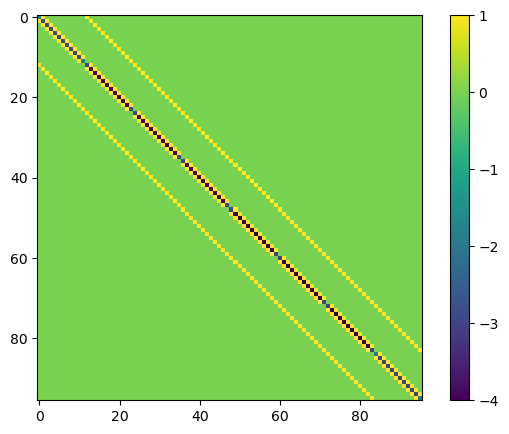

In [5]:
plt.imshow(L)
plt.grid(visible=False)
plt.colorbar()

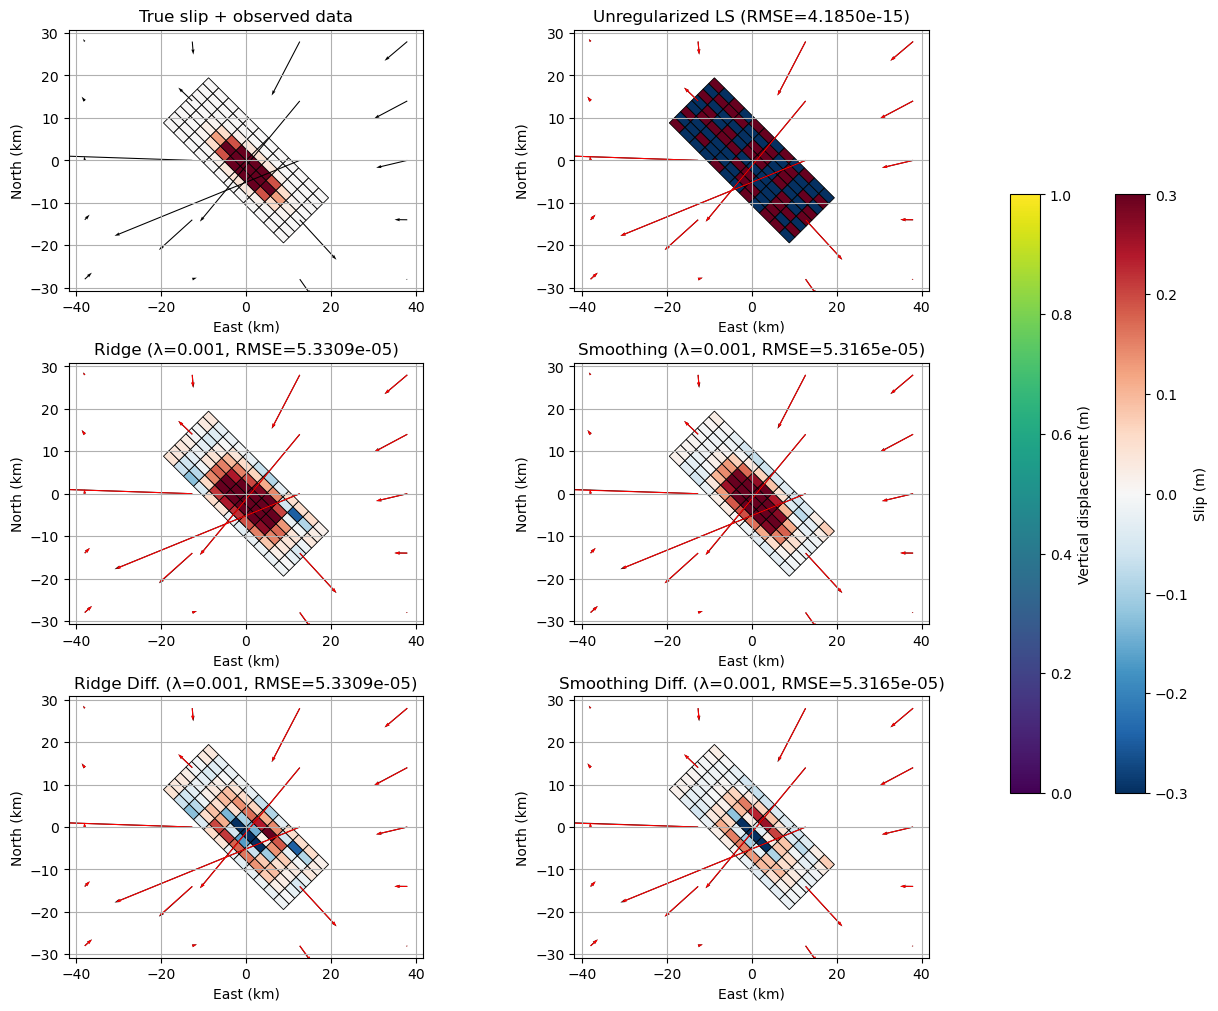

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), constrained_layout=True)

all_slips = np.hstack([s_true, s_ls, s_ridge, s_smooth])
vmin, vmax = -float(np.max(s_true)/4), float(np.max(s_true)/4)
#vmin, vmax = float(np.min(all_slips)), float(np.max(all_slips))

# calculate rmse
rmse_ls = rmse(np.concatenate([pred['LS'][0], pred['LS'][1], pred['LS'][2]]), d)
rmse_ridge = rmse(np.concatenate([pred['Ridge'][0], pred['Ridge'][1], pred['Ridge'][2]]), d)
rmse_smooth = rmse(np.concatenate([pred['Smooth'][0], pred['Smooth'][1], pred['Smooth'][2]]), d)

panels = [
    ('True slip + observed data', s_true, uE_obs, uN_obs, uU_obs, None, None),
    (f'Unregularized LS (RMSE={rmse_ls:.4e})', s_ls, uE_obs, uN_obs, uU_obs, pred['LS'][0], pred['LS'][1]),
    (f'Ridge (λ={lam_ridge}, RMSE={rmse_ridge:.4e})', s_ridge, uE_obs, uN_obs, uU_obs, pred['Ridge'][0], pred['Ridge'][1]),
    (f'Smoothing (λ={lam_smooth}, RMSE={rmse_smooth:.4e})', s_smooth, uE_obs, uN_obs, uU_obs, pred['Smooth'][0], pred['Smooth'][1]),
    (f'Ridge Diff. (λ={lam_ridge}, RMSE={rmse_ridge:.4e})', s_ridge-s_true, uE_obs, uN_obs, uU_obs, pred['Ridge'][0], pred['Ridge'][1]),
    (f'Smoothing Diff. (λ={lam_smooth}, RMSE={rmse_smooth:.4e})', s_smooth-s_true, uE_obs, uN_obs, uU_obs, pred['Smooth'][0], pred['Smooth'][1]),
]

mapper = None
scat = None
for ax, (title, slip, uE_map, uN_map, uU_map, uE_pred_map, uN_pred_map) in zip(axes.ravel(), panels):
    mapper = plot_fault_patches(ax, patches, slip, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    scat = plot_data_overlay(ax, obs_e, obs_n, uE_map, uN_map, None, uE_pred=uE_pred_map, uN_pred=uN_pred_map, quiver_step=1, quiver_scale=0.05)
    ax.set_title(title)
    ax.set_xlabel('East (km)')
    ax.set_ylabel('North (km)')
    ax.set_aspect('equal')

cbar1 = plt.colorbar(mapper, ax=axes, fraction=0.03, pad=0.02)
cbar1.set_label('Slip (m)')

cbar2 = plt.colorbar(scat, ax=axes, fraction=0.03, pad=0.08)
cbar2.set_label('Vertical displacement (m)')

plt.show()

## Summary
- You compared unregularized, ridge, and smoothing inversions.
- You used the same map-view visualization for all models.
- Regularization mainly suppresses unrealistic patch-to-patch variability.

## 2. Inversion with Non-Negative Constraint

We repeat the inversions but require $s \ge 0$ for all patches.

In [7]:
# Bounds for non-negative slip
bounds = (0, np.inf)

# Non-negative unregularized least squares
res_ls = lsq_linear(G, d, bounds=bounds)
s_ls_nn = res_ls.x

# Non-negative Ridge regularization
res_ridge = lsq_linear(G_ridge, d_ridge, bounds=bounds)
s_ridge_nn = res_ridge.x

# Non-negative Smoothing regularization
res_smooth = lsq_linear(G_smooth, d_smooth, bounds=bounds)
s_smooth_nn = res_smooth.x

# Predicted data for non-negative models
pred_nn = {
    "LS": (GE @ s_ls_nn, GN @ s_ls_nn, GU @ s_ls_nn),
    "Ridge": (GE @ s_ridge_nn, GN @ s_ridge_nn, GU @ s_ridge_nn),
    "Smooth": (GE @ s_smooth_nn, GN @ s_smooth_nn, GU @ s_smooth_nn),
}

print("Non-Negative Inversion Results:")
for name, (pe, pn, pu) in pred_nn.items():
    fit = rmse(np.concatenate([pe, pn, pu]), d)
    print(f"{name:10s} total RMSE = {fit:.4e}")

Non-Negative Inversion Results:
LS         total RMSE = 2.1848e-05
Ridge      total RMSE = 7.5042e-05
Smooth     total RMSE = 1.0334e-04


### Plot results (Non-Negative)

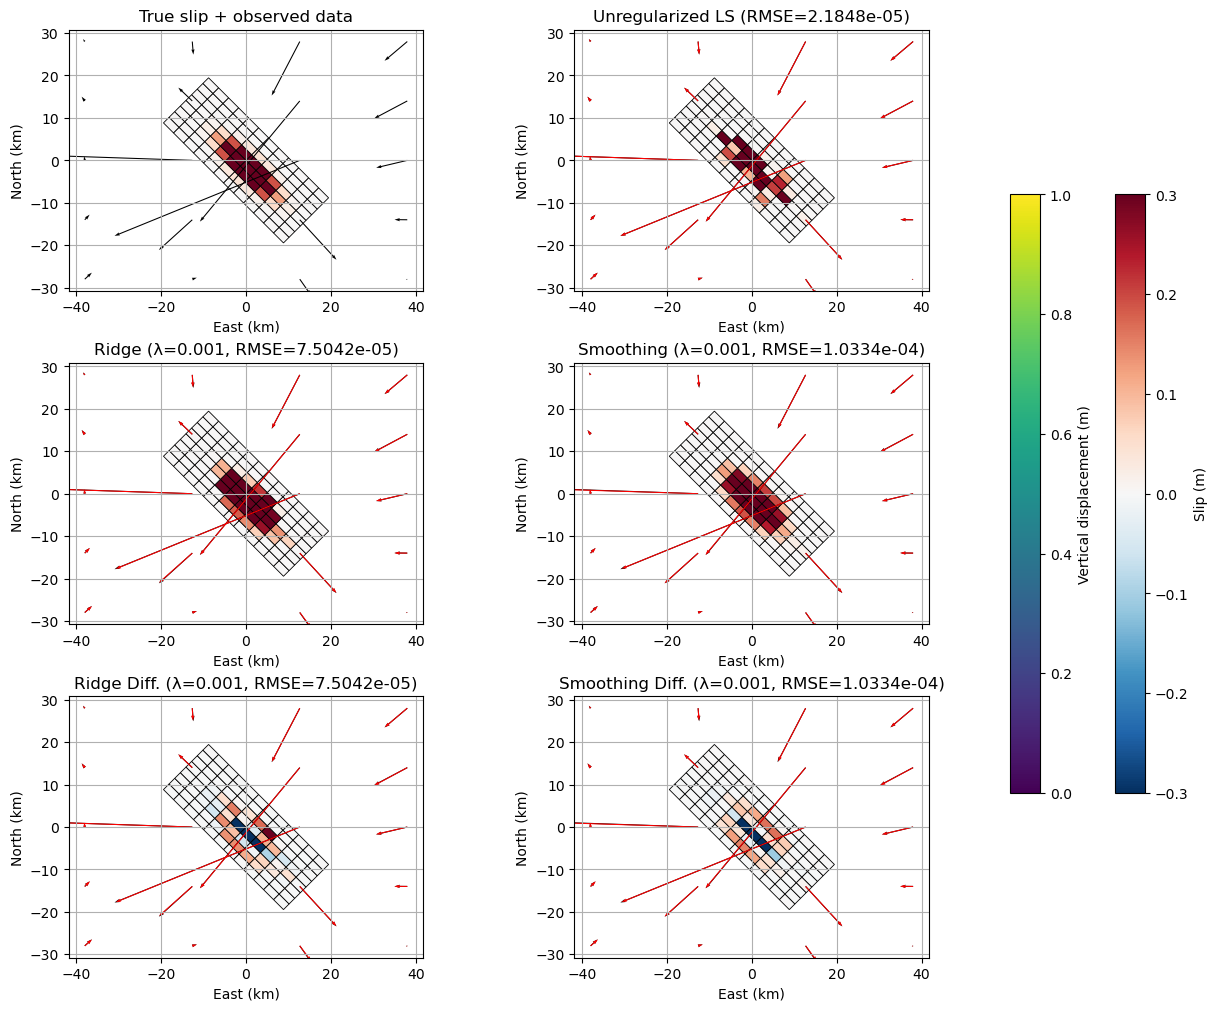

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), constrained_layout=True)

all_slips = np.hstack([s_true, s_ls, s_ridge, s_smooth])
vmin, vmax = -float(np.max(s_true)/4), float(np.max(s_true)/4)
#vmin, vmax = float(np.min(all_slips)), float(np.max(all_slips))

# calculate rmse
rmse_ls = rmse(np.concatenate([pred_nn['LS'][0], pred_nn['LS'][1], pred_nn['LS'][2]]), d)
rmse_ridge = rmse(np.concatenate([pred_nn['Ridge'][0], pred_nn['Ridge'][1], pred_nn['Ridge'][2]]), d)
rmse_smooth = rmse(np.concatenate([pred_nn['Smooth'][0], pred_nn['Smooth'][1], pred_nn['Smooth'][2]]), d)

panels = [
    ('True slip + observed data', s_true, uE_obs, uN_obs, uU_obs, None, None),
    (f'Unregularized LS (RMSE={rmse_ls:.4e})', s_ls_nn, uE_obs, uN_obs, uU_obs, pred['LS'][0], pred['LS'][1]),
    (f'Ridge (λ={lam_ridge}, RMSE={rmse_ridge:.4e})', s_ridge_nn, uE_obs, uN_obs, uU_obs, pred['Ridge'][0], pred['Ridge'][1]),
    (f'Smoothing (λ={lam_smooth}, RMSE={rmse_smooth:.4e})', s_smooth_nn, uE_obs, uN_obs, uU_obs, pred['Smooth'][0], pred['Smooth'][1]),
    (f'Ridge Diff. (λ={lam_ridge}, RMSE={rmse_ridge:.4e})', s_ridge_nn-s_true, uE_obs, uN_obs, uU_obs, pred['Ridge'][0], pred['Ridge'][1]),
    (f'Smoothing Diff. (λ={lam_smooth}, RMSE={rmse_smooth:.4e})', s_smooth_nn-s_true, uE_obs, uN_obs, uU_obs, pred['Smooth'][0], pred['Smooth'][1]),
]

mapper = None
scat = None
for ax, (title, slip, uE_map, uN_map, uU_map, uE_pred_map, uN_pred_map) in zip(axes.ravel(), panels):
    mapper = plot_fault_patches(ax, patches, slip, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    scat = plot_data_overlay(ax, obs_e, obs_n, uE_map, uN_map, None, uE_pred=uE_pred_map, uN_pred=uN_pred_map, quiver_step=1, quiver_scale=0.05)
    ax.set_title(title)
    ax.set_xlabel('East (km)')
    ax.set_ylabel('North (km)')
    ax.set_aspect('equal')

cbar1 = plt.colorbar(mapper, ax=axes, fraction=0.03, pad=0.02)
cbar1.set_label('Slip (m)')

cbar2 = plt.colorbar(scat, ax=axes, fraction=0.03, pad=0.08)
cbar2.set_label('Vertical displacement (m)')

plt.show()

